# Lung Cancer Dataset: EDA and Machine Learning

This notebook explores patterns related to lung cancer survival and tests a simple logistic regression model.


## 1. Import the Dataset
Load the libraries and lung cancer dataset.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("lung_cancer_dataset.csv")


## 2. Inspect the Data
Preview the dataset, review data types and summary statistics, and check the data for duplicates and missing values.


In [2]:
# Preview the first five rows
df.head()


,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,5,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,5,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,3,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,6,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,5,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


In [3]:
# Check the number of observations, columns, data types, and non-null values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Diagnosis_Year           2000 non-null   int64  
 2   Diagnosis_Date           2000 non-null   object 
 3   WHO_Region               2000 non-null   object 
 4   Country                  2000 non-null   object 
 5   Age                      2000 non-null   int64  
 6   Age_Group                2000 non-null   object 
 7   Gender                   2000 non-null   object 
 8   Smoking_Status           2000 non-null   object 
 9   Cigarettes_Per_Day       2000 non-null   int64  
 10  Years_Smoking            2000 non-null   int64  
 11  Pack_Years               2000 non-null   float64
 12  Secondhand_Smoke         2000 non-null   object 
 13  Family_History           2000 non-null   object 
 14  Occupational_Hazard     

In [4]:
# Summary statistics for numerical columns
df.describe()


,Diagnosis_Year,Age,Cigarettes_Per_Day,Years_Smoking,Pack_Years,BMI,Risk_Factor_Count,Symptom_Count,Tumor_Size_cm,Survival_Months
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2021.262000,60.749000,7.274000,8.115500,8.931150,26.544500,1.709500,3.338000,4.548050,31.755500
std,3.279746,10.337235,11.673734,12.682846,16.425992,4.045706,1.079672,1.620824,2.372069,23.838076
min,2015.000000,30.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.500000,1.000000
25%,2019.000000,53.000000,0.000000,0.000000,0.000000,23.800000,1.000000,2.000000,2.600000,11.000000
50%,2022.000000,60.000000,0.000000,0.000000,0.000000,26.500000,2.000000,3.000000,4.300000,26.000000
75%,2024.000000,68.000000,14.000000,16.000000,12.000000,29.325000,2.000000,4.000000,6.200000,49.000000
max,2026.000000,89.000000,56.000000,59.000000,106.000000,40.000000,6.000000,9.000000,13.300000,110.000000


In [5]:
# Check for duplicate rows
df.duplicated().sum()


0

In [6]:
# Confirm that patient IDs are unique
df["Patient_ID"].nunique()


2000

In [ ]:
# Check for missing values
df.isna().sum()


## 3. Prepare the Survival Variable
Convert `Survived` from Yes/No to 1/0 so survival rates can be calculated using the mean.


In [7]:
# Convert survival status to a numerical variable
df["Survived_num"] = df["Survived"].map({
    "Yes": 1,
    "No": 0
})

df.head()


,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Survived_num
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No,0
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes,1
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No,0
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No,0
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes,1


## 4. Survival Rate by Cancer Stage
Group patients by cancer stage and compare both survival rate and patient count.


In [8]:
# Calculate survival rate and patient count for each cancer stage
stage_survival = df.groupby("Cancer_Stage")["Survived_num"].agg(["mean", "count"])

# Convert survival rate to a percentage
stage_survival["mean"] = stage_survival["mean"] * 100

# Rename columns for readability
stage_survival = stage_survival.rename(columns={
    "mean": "Survival_Rate",
    "count": "Patient_Count"
})

stage_survival


,Survival_Rate,Patient_Count
Cancer_Stage,,
Stage I,69.844021,577
Stage II,50.718686,487
Stage III,17.391304,460
Stage IV,5.462185,476


**Finding:** Survival rate decreases sharply as cancer stage advances. Stage I has the highest survival rate, while Stage IV has the lowest.


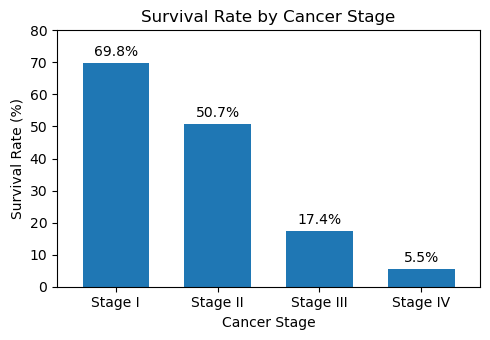

In [9]:
# Visualize survival rate across cancer stages
ax = stage_survival["Survival_Rate"].plot(
    kind="bar",
    figsize=(5, 3.5),
    width=0.65
)

plt.xlabel("Cancer Stage")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Cancer Stage")
plt.ylim(0, 80)
plt.xticks(rotation=0)

# Add percentage labels above each bar
ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()


## 5. Filter Stage I and Stage IV Patients
Since Stage I and Stage IV had the largest difference in survival rates, compare smoking status between these two groups.


In [10]:
# Keep only Stage I and Stage IV patients
stage_1_4 = df[
    (df["Cancer_Stage"] == "Stage I") |
    (df["Cancer_Stage"] == "Stage IV")
]

stage_1_4.head()


,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Survived_num
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No,0
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes,1
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No,0
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No,0
9,LC-0010,2022,2022-07-08,Europe,Poland,43,40-49,Male,Never Smoked,0,...,NSCLC,Adenocarcinoma,Stage I,1.5,No,LDCT Screening,Surgery,65,Yes,1


In [11]:
# Count smoking-status categories within each selected cancer stage
smoking_by_stage = stage_1_4.groupby(
    ["Cancer_Stage", "Smoking_Status"]
).size().unstack()

smoking_by_stage


Smoking_Status,Current Smoker,Former Smoker,Never Smoked
Cancer_Stage,,,
Stage I,61,46,470
Stage IV,169,58,249


**Finding:** Stage IV has more current smokers, while Stage I has more patients who never smoked. This is an association in the dataset, not evidence of causation.


## 6. Tumor Size vs. Survival Months
Use a scatter plot to explore the relationship between two numerical variables.


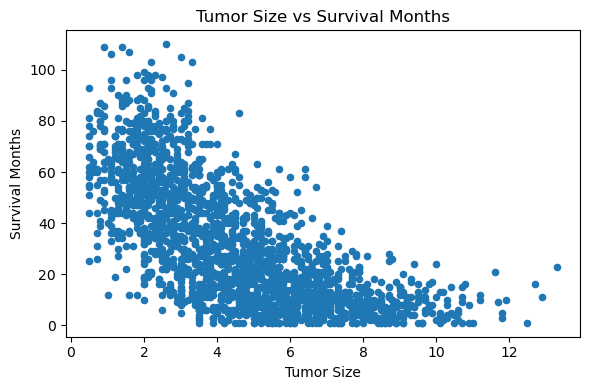

In [12]:
# Plot tumor size against survival time
df.plot(
    kind="scatter",
    x="Tumor_Size_cm",
    y="Survival_Months",
    figsize=(6, 4)
)

plt.xlabel("Tumor Size (cm)")
plt.ylabel("Survival Months")
plt.title("Tumor Size vs Survival Months")

plt.tight_layout()
plt.show()


In [13]:
# Measure the linear relationship between tumor size and survival months
df["Tumor_Size_cm"].corr(df["Survival_Months"])


-0.6906516545820909

**Finding:** Tumor size and survival months have a fairly strong negative correlation (about -0.69), so larger tumors tend to be associated with shorter survival times in this dataset.


## 7. Machine Learning: Logistic Regression

**Question:** Can patient characteristics be used to predict whether a patient survives?

For this first model, use cancer stage, tumor size, and age as predictors.


In [14]:
# Encode cancer stage as an ordered numerical variable
df["Stage_num"] = df["Cancer_Stage"].map({
    "Stage I": 1,
    "Stage II": 2,
    "Stage III": 3,
    "Stage IV": 4
})

df.head()


,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,...,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived,Survived_num,Stage_num
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,...,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No,0,4
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,...,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes,1,1
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,...,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No,0,1
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,...,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No,0,4
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,...,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes,1,3


In [15]:
# Select model inputs (X) and the target variable (y)
X = df[["Stage_num", "Tumor_Size_cm", "Age"]]
y = df["Survived_num"]


In [16]:
from sklearn.model_selection import train_test_split

# Use 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [17]:
# Number of rows and features in the training set
X_train.shape


(1600, 3)

In [18]:
# Number of rows and features in the test set
X_test.shape


(400, 3)

In [19]:
from sklearn.linear_model import LogisticRegression

# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [20]:
# Predict survival outcomes for the test set
y_pred = model.predict(X_test)

# Preview the first 10 predictions
y_pred[:10]


array([1, 1, 1, 0, 0, 0, 1, 0, 0, 1])

In [21]:
from sklearn.metrics import accuracy_score

# Measure the percentage of correct predictions
accuracy_score(y_test, y_pred)


0.75

**Model result:** The logistic regression model achieved an accuracy of 75% on the test data. This is an initial experiment with a small set of predictors.
